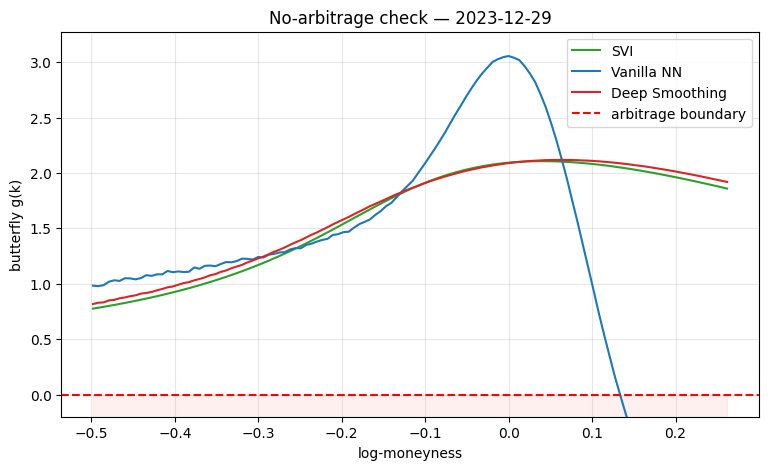

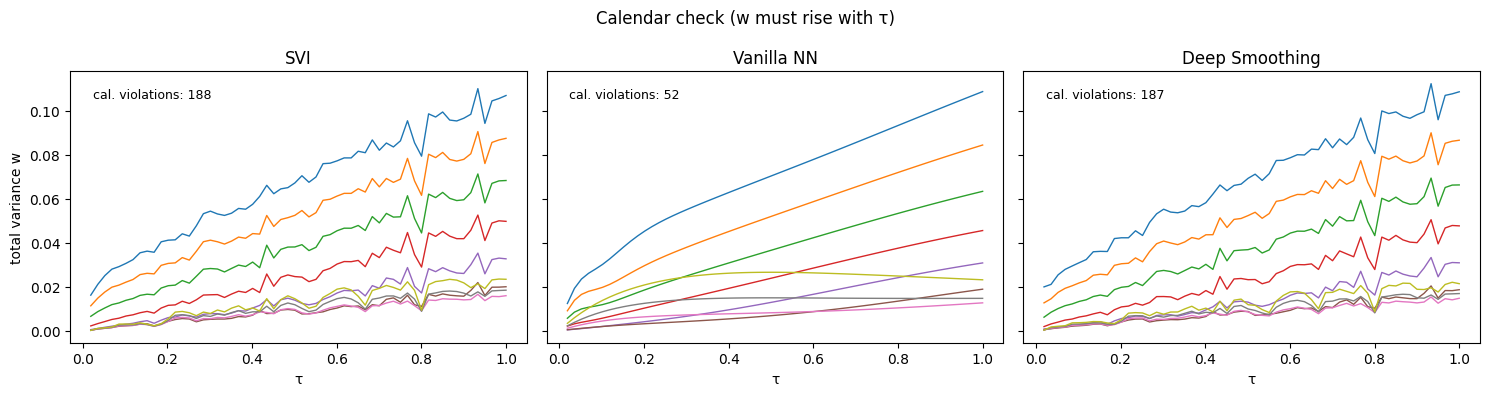

In [10]:
# ---- PLOT arbitrage curves from saved data  --------------
import pickle, numpy as np, matplotlib.pyplot as plt

#DRIVE="./training_results/"
#TICKER="SPX"

A = pickle.load(open(f"options_project/training_results/arb_curves_SPX.pkl","rb"))
COLORS = {"SVI":"#2ca02c","Vanilla NN":"#1f77b4","Deep Smoothing":"#d62728"}

# butterfly g(k)
plt.figure(figsize=(9,5))
for name, g in A["g"].items():
    plt.plot(A["kline"], g, label=name, color=COLORS.get(name))
plt.axhline(0, color="red", ls="--", lw=1.5, label="arbitrage boundary")
plt.fill_between(A["kline"], -1, 0, color="red", alpha=0.06)
plt.ylim(bottom=-0.2); plt.xlabel("log-moneyness"); plt.ylabel("butterfly g(k)")
plt.title(f"No-arbitrage check — {A['day']}"); plt.legend(); plt.grid(alpha=0.3); plt.show()

# calendar: w vs tau at fixed k (each method a subplot)
fig, axes = plt.subplots(1, len(A["cal"]), figsize=(15,4), sharey=True)
for ax,(name, lines) in zip(axes, A["cal"].items()):
    for j, k0 in enumerate(A["k_fixed"]):
        ax.plot(A["tau_fine"], lines[j], lw=1)
    ax.set_title(name); ax.set_xlabel("τ")
    viol = int(sum((np.diff(l) < 0).sum() for l in lines))
    ax.text(0.05, 0.9, f"cal. violations: {viol}", transform=ax.transAxes, fontsize=9)
axes[0].set_ylabel("total variance w"); plt.suptitle("Calendar check (w must rise with τ)")
plt.tight_layout(); plt.show()